<a href="https://colab.research.google.com/github/Jirtus-sanasam/MLP-Diabetes/blob/main/DiabetesEDA1_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('/content/diabetes_data2.csv')

In [3]:
cols_invalid_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']
cols_valid_zero = ['Pregnancies', 'DiabetesPedigreeFunction']

In [4]:
df[cols_invalid_zero] = df[cols_invalid_zero].replace(0, np.nan)

In [5]:
# Check missing values after replacement
print(df[cols_invalid_zero].isnull().sum())

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
Age                0
dtype: int64


In [6]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

imputer = IterativeImputer(random_state=42, max_iter=10)
df[cols_invalid_zero] = imputer.fit_transform(df[cols_invalid_zero])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    int64  
dtypes: float64(7), int64(2)
memory usage: 54.1 KB


In [8]:
X = df.drop('Outcome', axis=1)
Y = df['Outcome']

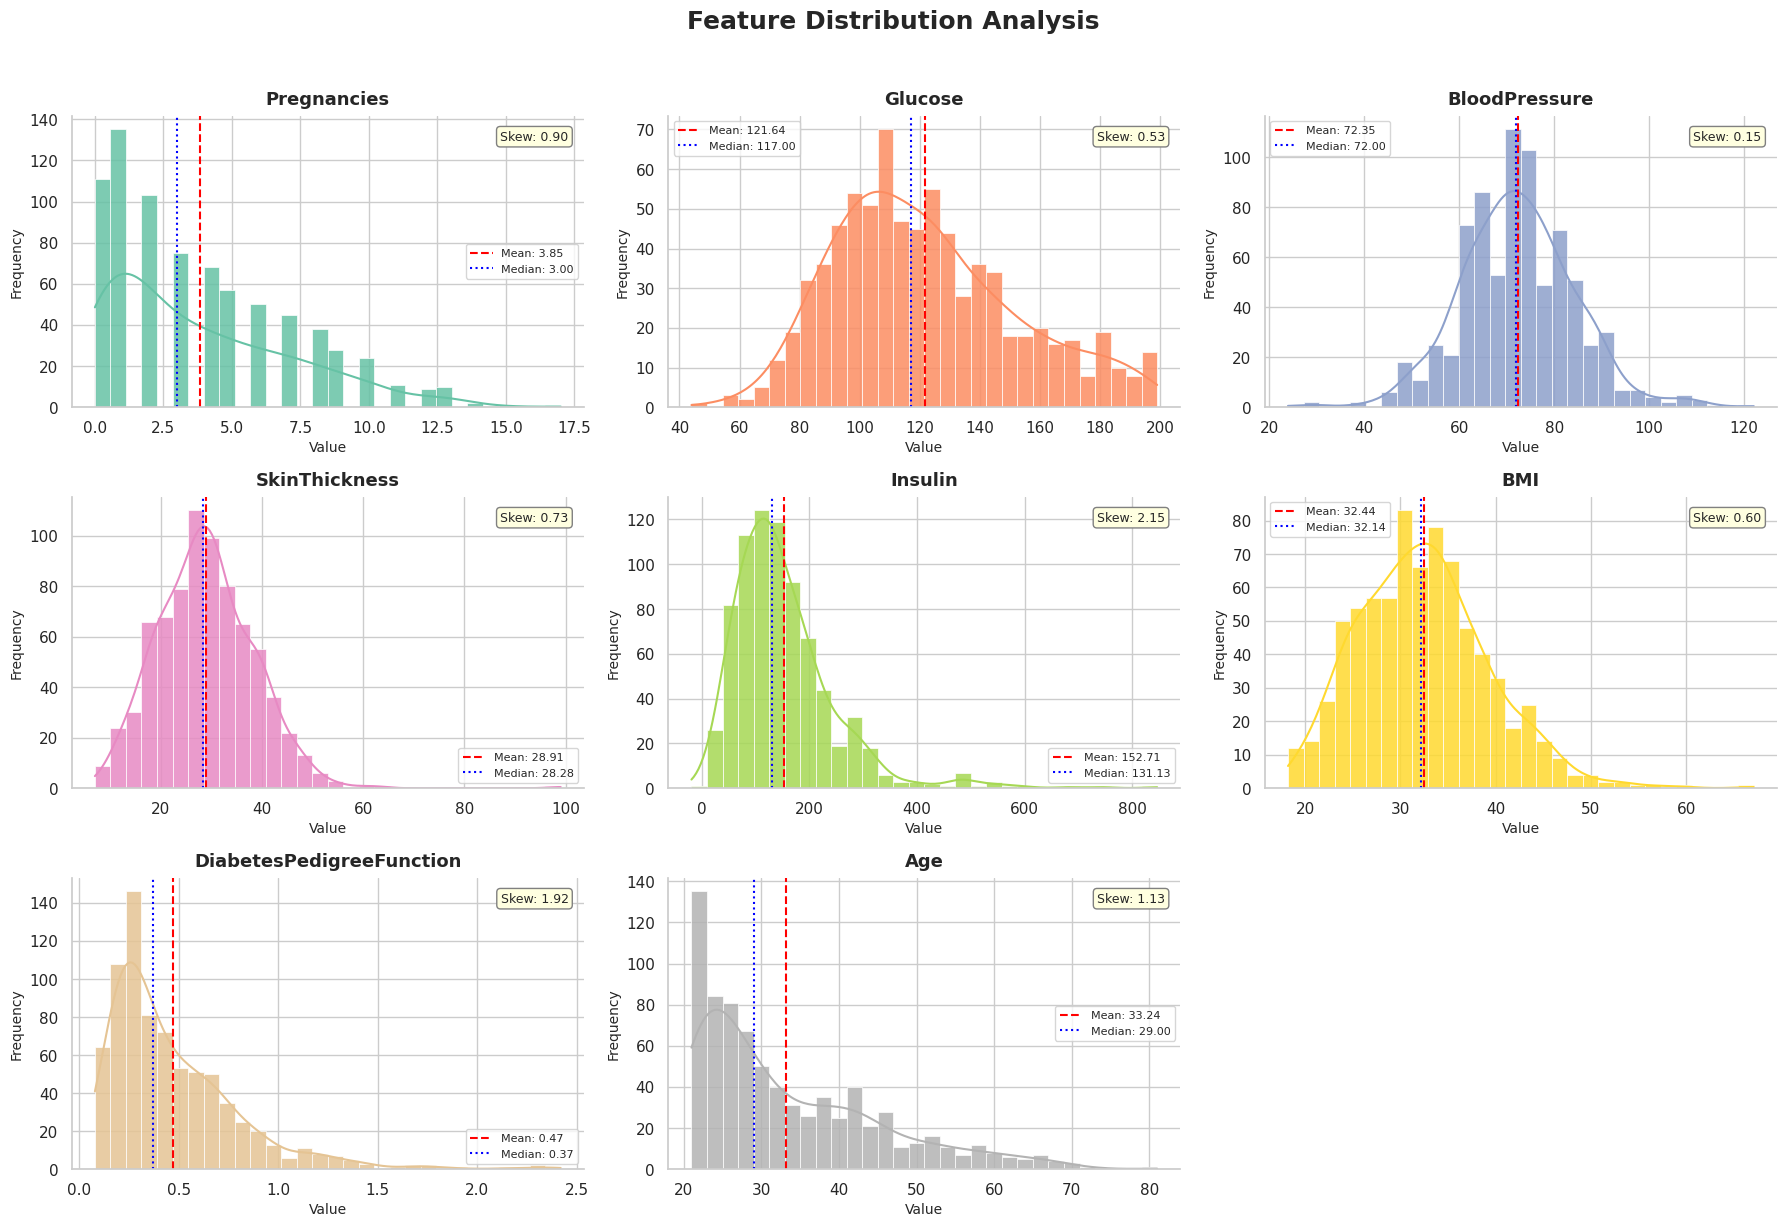

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# Style setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 11})

cols = X.columns.tolist()
n_cols = 3
n_rows = (len(cols) + n_cols - 1) // n_cols  # dynamic row count

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

colors = sns.color_palette("Set2", len(cols))

for i, col in enumerate(cols):
    ax = axes[i]
    data = X[col].dropna()

    # Histogram + KDE
    sns.histplot(data, ax=ax, color=colors[i], kde=True, bins=30,
                 edgecolor='white', linewidth=0.5, alpha=0.85)

    # Mean & Median lines
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='blue',   linestyle=':',  linewidth=1.5, label=f'Median: {data.median():.2f}')

    # Skewness annotation
    skewness = data.skew()
    ax.text(0.97, 0.95, f'Skew: {skewness:.2f}',
            transform=ax.transAxes, fontsize=9,
            ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

    ax.set_title(col, fontsize=13, fontweight='bold', pad=8)
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distribution Analysis', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

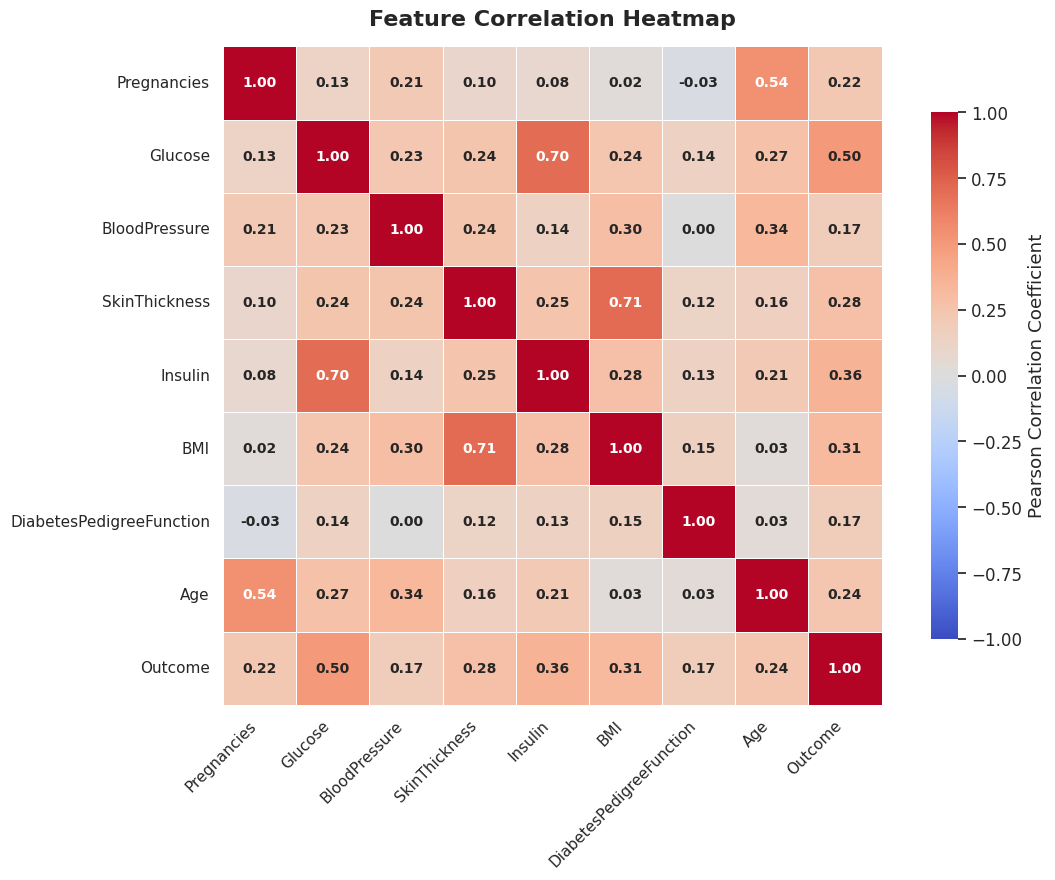

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white", font_scale=1.1)

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,                        # centers colormap at 0
    vmin=-1, vmax=1,                 # fixed scale
    linewidths=0.5,                  # grid lines between cells
    linecolor='white',
    annot_kws={"size": 10, "weight": "bold"},
    square=True,                     # keeps cells square
    cbar_kws={"shrink": 0.8, "label": "Pearson Correlation Coefficient"}
)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

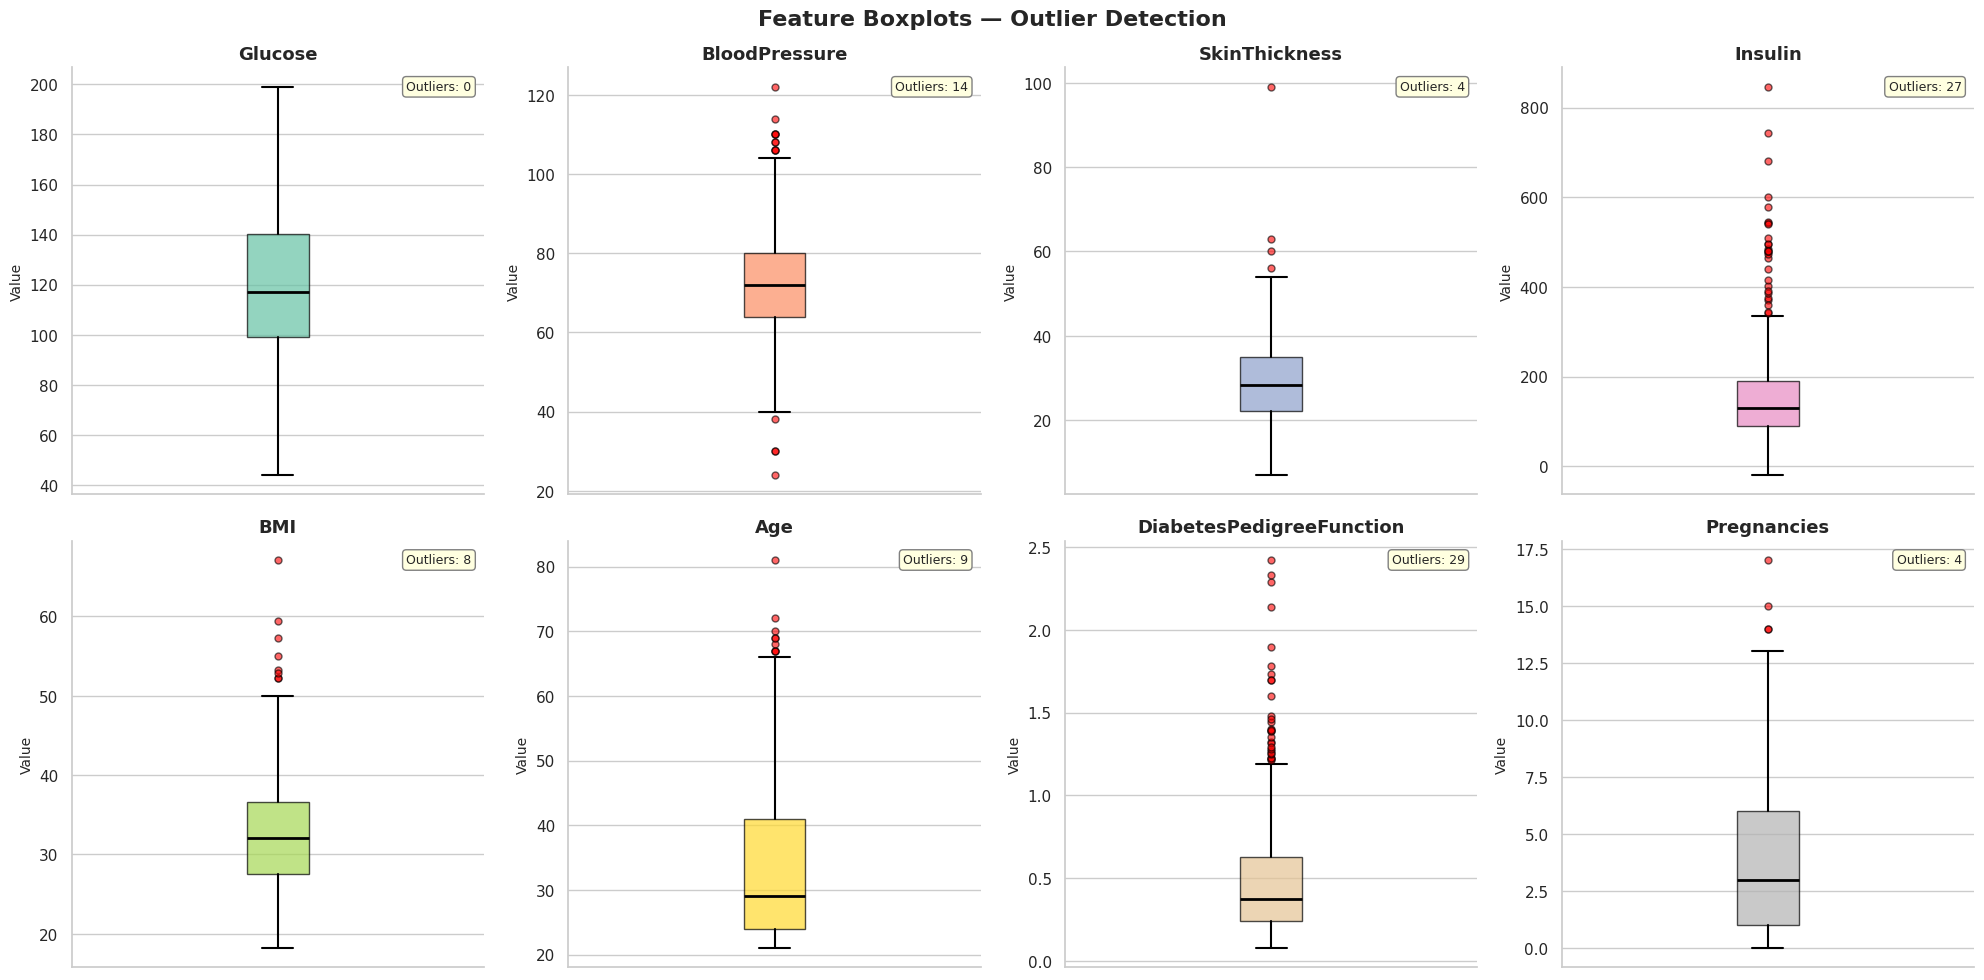

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")

cols = ['Glucose', 'BloodPressure', 'SkinThickness',
        'Insulin', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Pregnancies']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

colors = sns.color_palette("Set2", len(cols))

for i, col in enumerate(cols):
    ax = axes[i]
    data = df[col].dropna()

    # Boxplot
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                   markersize=5, alpha=0.6, linestyle='none'))

    # IQR outlier count annotation
    Q1  = data.quantile(0.25)
    Q3  = data.quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data < Q1 - 1.5 * IQR) | (data > Q3 + 1.5 * IQR)]

    ax.set_title(col, fontsize=13, fontweight='bold')
    ax.set_ylabel('Value', fontsize=10)
    ax.set_xticks([])
    ax.text(0.97, 0.97, f'Outliers: {len(outliers)}',
            transform=ax.transAxes, fontsize=9, ha='right', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

    sns.despine(ax=ax, left=False)

fig.suptitle('Feature Boxplots — Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('boxplots.png', dpi=300, bbox_inches='tight')
plt.show()